In [1]:
# Jupyter notebook to explore the DC sewage leak

In [21]:
# --- Standard library imports ---
import os                     # Operating system utilities (paths, mkdir, environment)
import sys                    # System-specific parameters and functions
import re                     # Regular expressions (parsing native_id, filenames)
import glob                   # Unix-style pathname pattern expansion (file discovery)
import warnings               # Emit and control warning messages
from collections import defaultdict  # Dict subclass with default factory
from io import BytesIO        # In-memory binary streams (images, downloads)

# --- Scientific computing and data handling ---
import numpy as np            # Numerical arrays and operations
import xarray as xr           # Labeled multi-dimensional arrays (netCDF, etc.)
import pandas as pd           # Tabular data handling (CSV/Excel)

# --- Parallel / distributed computing ---
from dask.distributed import Client  # Dask client for parallel processing
import logging               # Logging for tracking events and errors

# --- Plotting and visualization ---
import matplotlib.pyplot as plt          # Main plotting library
import matplotlib.colors as mcolors      # Color utilities and colormap helpers
import matplotlib.dates as mdates        # Date formatting for plots
from matplotlib.colors import LogNorm, LinearSegmentedColormap, ListedColormap # Color normalization and custom colormaps
import imageio                           # Read/write animated images (GIFs)
from IPython.display import Image as gifImage # Display GIFs in Jupyter notebooks

# --- Image processing ---
from PIL import Image, ImageEnhance   # Pillow for image enhancement used in RGB rendering

# --- Oceanographic / color maps ---
import cmocean                         # Oceanographic colormaps (thermal, haline, balance, etc.)
import colormaps as cmaps              # Additional colormap utilities

# --- Geospatial plotting ---
import cartopy.crs as ccrs             # Cartopy coordinate reference system

# --- Web and cloud access ---
import earthaccess                     # NASA Earthdata cloud and data access client


# --- MLD access additions ---
from pathlib import Path
import requests

In [2]:
def load_first(path, var):
    """
    Open the first granule from a search result and derive mapping parameters.

    Purpose:
    - Load a representative granule
    - Reproject it to an L3M-like grid
    - Pad/clip to the analysis bounding box (global bbox variable expected)
    - Return the CRS, raster shape and transform to be reused when opening
      many granules with dask/rioxarray.

    Parameters
    ----------
    path : str
        Path to a representative granule.
    var : str
        Variable name to use for deriving the grid (e.g. 'chlor_a').

    Returns
    -------
    crs, shape, transform
        Values suitable for passing to rioxarray.reproject when opening other files.
    """
    datatree = xr.open_datatree(path, decode_timedelta=True)
    dataset = xr.merge(datatree.to_dict().values())
    dataset = dataset.set_coords(("longitude", "latitude"))

    var_data = dataset[var]  # single-granule variable to use for grid derivation
    var_data = var_data.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
    var_data = var_data.rio.write_crs("epsg:4326")

    # Reproject once to the canonical geographic grid
    var_L3M = var_data.rio.reproject(
        dst_crs="epsg:4326",
        src_geoloc_array=(
            var_data.coords["longitude"],
            var_data.coords["latitude"],
        ),
    )
    var_L3M = var_L3M.rename({"x": "longitude", "y": "latitude"})

    # Pad to the global bbox defined in the notebook so subsequent opens share the same grid
    var_L3M_aoi = var_L3M.rio.pad_box(
        minx=bbox[0],
        miny=bbox[1],
        maxx=bbox[2],
        maxy=bbox[3],
        constant_values=np.nan,
    )

    crs = var_L3M_aoi.rio.crs  # CRS for future reprojections
    shape = var_L3M_aoi.rio.shape
    transform = var_L3M_aoi.rio.transform()

    return crs, shape, transform

def coregister_granules(paths, crs, shape, transform, var_name):
    """
    Reproject and combine multiple Level-2 granules into a single xarray dataset.

    Workflow:
    - Launch a Dask Client
    - Map grid_match across the list of paths to produce futures (reprojected DataArrays)
    - Use xr.open_mfdataset with a lightweight preprocess to collect time attributes
    - Combine the gathered futures into a single xarray dataset concatenated along 'time'
    - Attach the time coordinate extracted from attrs

    Parameters
    ----------
    paths : list[str]
        List of file paths (granules) to process.
    crs, shape, transform : as returned by load_first
    var_name : str
        Variable name inside the granules to extract.

    Returns
    -------
    xarray.Dataset or DataArray
        Combined dataset with a 'time' dimension.
    """
    client = Client()
    client.run(_silence_worker)

    # Create reproject tasks in parallel
    futures = client.map(
        grid_match, paths, dst_crs=crs, dst_shape=shape, dst_transform=transform, variable=var_name
    )

    kwargs = {"combine": "nested", "concat_dim": "time"}
    # open a light dataset solely to collect time coordinates
    attrs = xr.open_mfdataset(paths, preprocess=time_from_attr, **kwargs)

    # gather the reprojected results and combine into a single dataset
    data = xr.combine_nested(client.gather(futures), concat_dim="time")
    data["time"] = attrs["time"]
    client.close()

    return data
def _silence_worker():
    """
    Set environment and logger levels on Dask workers to reduce noisy output.

    Returns
    -------
    bool
        Always returns True (used with client.run).
    """
    import os, warnings, logging

    os.environ.setdefault("PYTHONWARNINGS", "ignore")
    warnings.filterwarnings("ignore")
    logging.getLogger("distributed").setLevel(logging.ERROR)
    logging.getLogger("distributed.worker").setLevel(logging.ERROR)
    logging.getLogger("distributed.worker.memory").setLevel(logging.ERROR)
    logging.getLogger("tornado").setLevel(logging.ERROR)
    logging.getLogger("urllib3").setLevel(logging.ERROR)
    return True

def grid_match(path, dst_crs, dst_shape, dst_transform, variable):
    """
    Reproject a Level-2 granule variable into a common (L3M-like) geographic grid.

    This helper function opens a single granule stored as an xarray datatree, extracts the
    requested geophysical variable and reprojects it to the target grid specified
    by dst_crs / dst_shape / dst_transform. The function also renames the output
    spatial dimensions to 'longitude' and 'latitude' for consistency with the
    rest of the notebook.

    Parameters
    ----------
    path : str or Path
        Filesystem path (or cloud URL) to the granule to open.
    dst_crs : str
        Destination CRS (e.g. "epsg:4326") used by rioxarray.reproject.
    dst_shape : tuple
        Output array shape (ny, nx) for the reprojected grid.
    dst_transform : affine.Affine or similar
        Geospatial transform for the target grid.
    variable : str
        Name of the variable in the granule to extract (e.g. "chlor_a").

    Returns
    -------
    xarray.DataArray
        Reprojected data array with coords "longitude" and "latitude".
    """
    dt = xr.open_datatree(path, decode_timedelta=True)
    da = dt["geophysical_data"][variable]

    # Ensure rioxarray can interpret the L2 pixel axes
    da = da.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
    da = da.rio.write_crs("epsg:4326")

    # Reproject to the provided destination grid using the navigation arrays from the datatree
    da = da.rio.reproject(
        dst_crs,
        shape=dst_shape,
        transform=dst_transform,
        src_geoloc_array=(
            dt["navigation_data"]["longitude"],
            dt["navigation_data"]["latitude"],
        ),
    )

    # Standardize coordinate names used across the notebook
    da = da.rename({"x": "longitude", "y": "latitude"})
    return da

def time_from_attr(ds):
    """
    Create a 'time' coordinate from the dataset attribute 'time_coverage_start'.

    Many Level-2 granules include the acquisition time as an attribute. This
    routine parses that attribute, converts it to a numpy datetime64, and sets
    it as a coordinate so xarray concatenation by time is straightforward.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset loaded from a Level-2 granule that contains the attribute
        'time_coverage_start'.

    Returns
    -------
    xarray.Dataset
        Input dataset with an added 'time' coordinate.
    """
    datetime = ds.attrs["time_coverage_start"].replace("Z", "")
    ds["time"] = ((), np.datetime64(datetime, "ns"))
    ds = ds.set_coords("time")
    return ds


In [3]:
# Event Timeframes
# Complete event timespan
tspan = ("2026-01-17", "2026-02-15")
# Define pre-event and post-event timespans
pre_tspan = ("2026-01-17", "2026-01-23") 
post_tspan = ("2026-01-24", "2026-02-15") 

# Geographic information for event analysis
# Define latitudes and longitudes for area of interest
min_lon = -77.25
min_lat = 38.75
max_lon = -76.95
max_lat = 39
# Target point of interest (e.g., storm center along track with high data coverage. Look at data coverage maps to decide))

target_point = [38.78134088446387, -77.03709193725459]

# Set method for storing data. If working in the cloud and you would like to stream data, set boolean to True. Otherwise, set to False to download and work with data locally.
in_the_cloud = False


In [4]:
# Setup .ipynb filing using the users inputs

# Add HH:MM:SS (set to noon UTC) to temporal span for SST earthaccess query
tspan_with_time = (f"{tspan[0]} 12:00:00", f"{tspan[1]} 12:00:00")

# Construct bounding box
bbox = (min_lon, min_lat, max_lon, max_lat)

# Set path to store data locally if not working in the cloud
data_path = os.path.join(os.getcwd(), "local", "data")
if in_the_cloud == False:
    os.makedirs(data_path, exist_ok=True)
# Set path to store output images and figures
output_path = os.path.join(os.getcwd(), "local", "figures")
os.makedirs(output_path, exist_ok=True)

In [12]:
results_iop = earthaccess.search_data(
    short_name="PACE_OCI_L2_IOP",
    temporal=tspan,
    bounding_box=bbox,
    version="3.1"
)
if len(results_iop) != 0:# modified !=, quick fix, use only nrt for this
    print("No results found for reprocessed surface reflectance data product, searching for near real time product instead.")
    results_iop = earthaccess.search_data(
        short_name="PACE_OCI_L2_IOP_NRT",
        temporal=tspan,
        bounding_box=bbox,
        version="3.1"
    )
if in_the_cloud == True:
    paths_iop = earthaccess.open(results_iop)
else:
    paths_iop = earthaccess.download(results_iop, local_path=data_path)

print("Number of IOP granules: "+str(len(results_iop)))

No results found for reprocessed surface reflectance data product, searching for near real time product instead.


QUEUEING TASKS | :   0%|          | 0/50 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/50 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/50 [00:00<?, ?it/s]

Number of IOP granules: 50


In [6]:
paths_iop

['c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260117T171506.L2.OC_IOP.V3_1.nc',
 'c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260118T174503.L2.OC_IOP.V3_1.nc',
 'c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260119T164639.L2.OC_IOP.V3_1.nc',
 'c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260119T181959.L2.OC_IOP.V3_1.nc',
 'c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260120T171636.L2.OC_IOP.V3_1.nc',
 'c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260120T172136.L2.OC_IOP.V3_1.nc',
 'c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260121T175133.L2.OC_IOP.V3_1.nc',
 'c:\\Users\\gtrolle

In [ ]:
# # Close all existing clients
# for client in Client._instances:
#     client.close()

# crs_iop, shape_iop, transform_iop= load_first(paths_iop[0], "adg_442")
# data_iop = coregister_granules(paths_iop, crs_iop, shape_iop, transform_iop, "adg_442")

In [7]:
# import xarray as xr
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from PIL import Image
# import io
# from pathlib import Path

# # old function, assumes grid matched, but i dont want to do that for small spatial scales
# def create_map_gif_from_netcdf_files(file_paths, variable_name, output_file='map.gif', 
#                                       min_lon=-77.25, min_lat=38.75,
#                                       max_lon=-76.95, max_lat=39.0,
#                                       duration=500, vmin=None, vmax=None, 
#                                       cmap='viridis', figsize=(12, 8),
#                                       add_states=True, add_counties=False,
#                                       sort_files=True, group_path=None):
#     """
#     Create a GIF from a list of NetCDF files using datatree
    
#     Parameters:
#     -----------
#     file_paths : list of str
#         List of paths to NetCDF files
#     variable_name : str
#         Name of the data variable to plot
#     output_file : str
#         Output filename for the GIF
#     min_lon, min_lat, max_lon, max_lat : float
#         Map boundaries
#     duration : int
#         Duration of each frame in milliseconds
#     vmin, vmax : float
#         Min and max values for colorbar (if None, computed from all data)
#     cmap : str
#         Matplotlib colormap name
#     figsize : tuple
#         Figure size (width, height)
#     add_states : bool
#         Add state boundaries
#     add_counties : bool
#         Add county boundaries
#     sort_files : bool
#         Sort file paths alphabetically before processing
#     group_path : str
#         Path to group in datatree (e.g., 'geophysical_data' or 'sensor_band_parameters')
#     """
    
#     if sort_files:
#         file_paths = sorted(file_paths)
    
#     print(f"Processing {len(file_paths)} NetCDF files...")
    
#     # Check first file to understand structure
#     print(f"\nInspecting first file: {Path(file_paths[0]).name}")
#     dt = xr.open_datatree(file_paths[0], decode_timedelta=True)
#     print(f"Datatree groups: {list(dt.children.keys())}")
    
#     # Try to find the variable
#     found = False
#     found_group = None
    
#     # Check root level
#     if variable_name in dt.ds:
#         print(f"✓ Found '{variable_name}' in root dataset")
#         found = True
#         found_group = None
    
#     # Check in groups
#     for group_name, group in dt.children.items():
#         if variable_name in group.ds:
#             print(f"✓ Found '{variable_name}' in group '{group_name}'")
#             found = True
#             found_group = group_name
#             break
#         print(f"  Group '{group_name}' variables: {list(group.ds.data_vars)[:5]}...")  # Show first 5
    
#     if not found and group_path:
#         # User specified a group path
#         try:
#             group = dt[group_path]
#             if variable_name in group.ds:
#                 print(f"✓ Found '{variable_name}' in specified group '{group_path}'")
#                 found = True
#                 found_group = group_path
#         except:
#             pass
    
#     if not found:
#         dt.close()
#         all_vars = []
#         for group_name, group in dt.children.items():
#             all_vars.extend([f"{group_name}/{var}" for var in group.ds.data_vars])
#         raise ValueError(f"Variable '{variable_name}' not found. Available variables:\n" + 
#                         "\n".join(all_vars[:20]))
    
#     # Use the found group or user-specified group
#     if group_path:
#         target_group = group_path
#     else:
#         target_group = found_group
    
#     print(f"Using group: {target_group if target_group else 'root'}")
#     dt.close()
    
#     # First pass: determine color scale if not provided
#     if vmin is None or vmax is None:
#         print("\nCalculating color scale from all files...")
#         all_min = []
#         all_max = []
#         for file_path in file_paths:
#             dt = xr.open_datatree(file_path, decode_timedelta=True)
#             if target_group:
#                 data = dt[target_group].ds[variable_name]
#             else:
#                 data = dt.ds[variable_name]
#             all_min.append(float(data.min()))
#             all_max.append(float(data.max()))
#             dt.close()
        
#         if vmin is None:
#             vmin = min(all_min)
#         if vmax is None:
#             vmax = max(all_max)
        
#         print(f"Color scale: vmin={vmin:.3f}, vmax={vmax:.3f}")
    
#     print(f"Map extent: [{min_lon}, {max_lon}] x [{min_lat}, {max_lat}]")
    
#     frames = []
#     for i, file_path in enumerate(file_paths):
#         # Load datatree
#         dt = xr.open_datatree(file_path, decode_timedelta=True)
        
#         # Get data from appropriate group
#         if target_group:
#             data = dt[target_group].ds[variable_name]
#         else:
#             data = dt.ds[variable_name]
        
#         # Subset to region of interest if lat/lon dims exist
#         try:
#             # Try common latitude/longitude names
#             lat_names = ['lat', 'latitude', 'Latitude', 'LAT']
#             lon_names = ['lon', 'longitude', 'Longitude', 'LON']
            
#             lat_dim = None
#             lon_dim = None
            
#             for name in lat_names:
#                 if name in data.dims or name in data.coords:
#                     lat_dim = name
#                     break
            
#             for name in lon_names:
#                 if name in data.dims or name in data.coords:
#                     lon_dim = name
#                     break
            
#             if lat_dim and lon_dim:
#                 # Subset to region
#                 data = data.sel({
#                     lat_dim: slice(min_lat, max_lat),
#                     lon_dim: slice(min_lon, max_lon)
#                 })
#         except Exception as e:
#             print(f"Warning: Could not subset data to region: {e}")
        
#         # Create figure
#         fig = plt.figure(figsize=figsize)
#         ax = plt.axes(projection=ccrs.PlateCarree())
        
#         # Set map extent
#         ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
        
#         # Add features
#         if add_states:
#             states = cfeature.NaturalEarthFeature(
#                 category='cultural',
#                 name='admin_1_states_provinces_lines',
#                 scale='10m',
#                 facecolor='none'
#             )
#             ax.add_feature(states, edgecolor='black', linewidth=1.5)
        
#         if add_counties:
#             counties = cfeature.NaturalEarthFeature(
#                 category='cultural',
#                 name='admin_2_counties',
#                 scale='10m',
#                 facecolor='none'
#             )
#             ax.add_feature(counties, edgecolor='gray', linewidth=0.5)
        
#         # Add coastlines and water bodies
#         ax.coastlines(resolution='10m', linewidth=1)
#         ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue', alpha=0.5)
#         ax.add_feature(cfeature.LAKES, alpha=0.3)
        
#         # Add gridlines
#         gl = ax.gridlines(draw_labels=True, alpha=0.5, linestyle='--', linewidth=0.5)
#         gl.top_labels = False
#         gl.right_labels = False
        
#         # Plot data
#         data.plot(
#             ax=ax, 
#             transform=ccrs.PlateCarree(),
#             vmin=vmin, 
#             vmax=vmax, 
#             cmap=cmap,
#             cbar_kwargs={'shrink': 0.8, 'pad': 0.05, 'label': variable_name}
#         )
        
#         # Title with filename or timestamp
#         filename = Path(file_path).name
#         title = f'{variable_name} - {filename}'
        
#         # Try to get timestamp from data if available
#         if target_group:
#             ds = dt[target_group].ds
#         else:
#             ds = dt.ds
            
#         if 'time' in ds:
#             try:
#                 timestamp = ds['time'].values
#                 title = f'{variable_name} - Time: {timestamp}'
#             except:
#                 pass
        
#         ax.set_title(title, fontsize=12, pad=10)
        
#         # Convert to image
#         buf = io.BytesIO()
#         plt.savefig(buf, format='png', bbox_inches='tight', dpi=150)
#         buf.seek(0)
#         frames.append(Image.open(buf).copy())
#         plt.close()
#         buf.close()
#         dt.close()
        
#         if (i + 1) % 10 == 0:
#             print(f"Processed {i + 1}/{len(file_paths)} frames")
    
#     # Save as GIF
#     frames[0].save(output_file, save_all=True, append_images=frames[1:],
#                    duration=duration, loop=0)
    
#     print(f"\n✓ GIF saved to {output_file} with {len(frames)} frames")
    
#     return output_file


# # Helper function to explore datatree structure
# def inspect_datatree(file_path):
#     """Helper function to inspect datatree structure"""
#     print(f"\n{'='*60}")
#     print(f"Inspecting: {Path(file_path).name}")
#     print(f"{'='*60}")
    
#     dt = xr.open_datatree(file_path, decode_timedelta=True)
    
#     print("\nDatatree Structure:")
#     print(dt)
    
#     print("\n\nGroups and Variables:")
#     print("-" * 60)
    
#     # Root level
#     if len(dt.ds.data_vars) > 0:
#         print("\nROOT level variables:")
#         for var in dt.ds.data_vars:
#             print(f"  - {var}: {dt.ds[var].dims}, shape={dt.ds[var].shape}")
    
#     # Groups
#     for group_name, group in dt.children.items():
#         print(f"\nGroup: '{group_name}'")
#         if len(group.ds.data_vars) > 0:
#             for var in list(group.ds.data_vars)[:10]:  # First 10 variables
#                 print(f"  - {var}: {group.ds[var].dims}, shape={group.ds[var].shape}")
#             if len(group.ds.data_vars) > 10:
#                 print(f"  ... and {len(group.ds.data_vars) - 10} more variables")
    
#     dt.close()
#     print(f"{'='*60}\n")

# # Usage:
# """
# # First inspect the structure
# inspect_datatree(paths_iop[0])

# # Then create the GIF
# create_map_gif_from_netcdf_files(
#     file_paths=paths_iop,
#     variable_name='adg_442',
#     output_file='chesapeake_bay.gif',
#     duration=500,
#     cmap='RdYlBu_r',
#     group_path='geophysical_data'  # Specify if needed
# )
# """

# create_map_gif_from_netcdf_files(
#     file_paths=paths_iop,
#     variable_name='bb',
#     output_file='chesapeake_bay_bb.gif',
#     duration=500,
#     cmap='RdYlBu_r',
#     group_path='geophysical_data'  # Specify if needed
# )

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from PIL import Image
import io
from pathlib import Path
import rioxarray

# good gif function
def create_map_gif_from_netcdf_files(file_paths, variable_name, 
                                      min_lon=-77.25, min_lat=38.75,
                                      max_lon=-76.95, max_lat=39.0,
                                      output_file='map.gif', 
                                      duration=500, vmin=None, vmax=None, 
                                      cmap='viridis', figsize=(12, 8),
                                      add_states=True, add_counties=False,
                                      sort_files=True, points=None):
    """
    Create a GIF from a list of PACE OCI NetCDF files
    
    Parameters:
    -----------
    file_paths : list of str
        List of paths to NetCDF files
    variable_name : str
        Name of the data variable to plot (from geophysical_data group)
    min_lon : float
        Minimum longitude for map extent (default: -77.25)
    min_lat : float
        Minimum latitude for map extent (default: 38.75)
    max_lon : float
        Maximum longitude for map extent (default: -76.95)
    max_lat : float
        Maximum latitude for map extent (default: 39.0)
    output_file : str
        Output filename for the GIF (default: 'map.gif')
    duration : int
        Duration of each frame in milliseconds (default: 500)
    vmin : float, optional
        Minimum value for colorbar. If None, computed from all data (default: None)
    vmax : float, optional
        Maximum value for colorbar. If None, computed from all data (default: None)
    cmap : str
        Matplotlib colormap name (default: 'viridis')
    figsize : tuple
        Figure size (width, height) (default: (12, 8))
    add_states : bool
        Add state boundaries (default: True)
    add_counties : bool
        Add county boundaries (default: False)
    sort_files : bool
        Sort file paths alphabetically before processing (default: True)
    points : list of tuples, optional
        List of (lon, lat) tuples to plot as red X markers on all frames
        Example: [(-76.5, 38.9), (-77.0, 39.0)]
        (default: None)
    """
    
    if sort_files:
        file_paths = sorted(file_paths)
    
    print(f"Processing {len(file_paths)} NetCDF files...")
    
    # Check first file to understand structure
    print(f"\nInspecting first file: {Path(file_paths[0]).name}")
    dt = xr.open_datatree(file_paths[0], decode_timedelta=True)
    da = dt["geophysical_data"][variable_name]
    
    # Ensure rioxarray can interpret the L2 pixel axes
    da = da.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
    da = da.rio.write_crs("epsg:4326")
    
    print(f"✓ Found '{variable_name}'")
    print(f"Data dimensions: {da.dims}")
    print(f"Data shape: {da.shape}")
    
    dt.close()
    
    # Display points information if provided
    if points is not None:
        print(f"\n✓ Will plot {len(points)} point(s) as red X markers:")
        for i, (lon, lat) in enumerate(points):
            print(f"  Point {i+1}: lon={lon:.4f}, lat={lat:.4f}")
    
    # Determine color scale if not provided
    if vmin is None or vmax is None:
        print("\nCalculating color scale from all files...")
        all_min = []
        all_max = []
        for file_path in file_paths:
            dt = xr.open_datatree(file_path, decode_timedelta=True)
            da = dt["geophysical_data"][variable_name]
            da = da.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
            da = da.rio.write_crs("epsg:4326")
            all_min.append(float(da.min()))
            all_max.append(float(da.max()))
            dt.close()
        
        if vmin is None:
            vmin = min(all_min)
            print(f"Auto vmin: {vmin:.3f}")
        else:
            print(f"Manual vmin: {vmin:.3f}")
            
        if vmax is None:
            vmax = max(all_max)
            print(f"Auto vmax: {vmax:.3f}")
        else:
            print(f"Manual vmax: {vmax:.3f}")
    else:
        print(f"\nUsing manual color scale:")
        print(f"vmin: {vmin:.3f}")
        print(f"vmax: {vmax:.3f}")
    
    print(f"Map extent: [{min_lon}, {max_lon}] x [{min_lat}, {max_lat}]")
    
    frames = []
    for i, file_path in enumerate(file_paths):
        # Load datatree
        dt = xr.open_datatree(file_path, decode_timedelta=True)
        da = dt["geophysical_data"][variable_name]
        
        # Ensure rioxarray can interpret the L2 pixel axes
        da = da.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
        da = da.rio.write_crs("epsg:4326")
        
        # Get longitude and latitude from navigation_data
        lon = dt["navigation_data"]["longitude"].values
        lat = dt["navigation_data"]["latitude"].values
        
        # Create figure
        fig = plt.figure(figsize=figsize)
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        # Set map extent
        ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
        
        # Add features
        if add_states:
            states = cfeature.NaturalEarthFeature(
                category='cultural',
                name='admin_1_states_provinces_lines',
                scale='10m',
                facecolor='none'
            )
            ax.add_feature(states, edgecolor='black', linewidth=1.5, zorder=3)
        
        if add_counties:
            counties = cfeature.NaturalEarthFeature(
                category='cultural',
                name='admin_2_counties',
                scale='10m',
                facecolor='none'
            )
            ax.add_feature(counties, edgecolor='gray', linewidth=0.5, zorder=3)
        
        # Add coastlines and water bodies
        ax.coastlines(resolution='10m', linewidth=1, zorder=3)
        ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue', alpha=0.5, zorder=2)
        ax.add_feature(cfeature.LAKES, alpha=0.3, zorder=2)
        
        # Add gridlines
        gl = ax.gridlines(draw_labels=True, alpha=0.5, linestyle='--', linewidth=0.5)
        gl.top_labels = False
        gl.right_labels = False
        
        # Plot data using pcolormesh with lon/lat
        try:
            mesh = ax.pcolormesh(
                lon, lat, da.values,
                transform=ccrs.PlateCarree(),
                vmin=vmin,
                vmax=vmax,
                cmap=cmap,
                shading='auto',
                zorder=1
            )
            
            # Add colorbar
            cbar = plt.colorbar(mesh, ax=ax, shrink=0.8, pad=0.05)
            cbar.set_label(variable_name, rotation=270, labelpad=20)
            
        except Exception as e:
            print(f"Error plotting frame {i}: {e}")
            dt.close()
            continue
        
        # Plot points as red X markers if provided
        if points is not None:
            for point_lon, point_lat in points:
                ax.plot(point_lon, point_lat, 'rx', 
                       markersize=10, markeredgewidth=1,
                       transform=ccrs.PlateCarree(), zorder=4)
        
        # Title with filename or timestamp
        filename = Path(file_path).name
        
        # Try to extract timestamp from filename (PACE format: YYYYMMDDTHHMMSS)
        try:
            import re
            match = re.search(r'(\d{8}T\d{6})', filename)
            if match:
                timestamp_str = match.group(1)
                from datetime import datetime
                timestamp = datetime.strptime(timestamp_str, '%Y%m%dT%H%M%S')
                title = f'{variable_name} - {timestamp.strftime("%Y-%m-%d %H:%M:%S UTC")}'
            else:
                title = f'{variable_name} - {filename}'
        except:
            title = f'{variable_name} - {filename}'
        
        ax.set_title(title, fontsize=12, pad=10)
        
        # Convert to image
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', dpi=150)
        buf.seek(0)
        frames.append(Image.open(buf).copy())
        plt.close()
        buf.close()
        dt.close()
        
        if (i + 1) % 10 == 0 or i == 0:
            print(f"Processed {i + 1}/{len(file_paths)} frames")
    
    # Save as GIF
    if len(frames) > 0:
        frames[0].save(output_file, save_all=True, append_images=frames[1:],
                       duration=duration, loop=0)
        print(f"\n✓ GIF saved to {output_file} with {len(frames)} frames")
    else:
        print(f"\n✗ No frames were created. Check errors above.")
    
    return output_file


# Helper function to explore datatree structure
def inspect_datatree(file_path):
    """Helper function to inspect PACE OCI datatree structure"""
    print(f"\n{'='*60}")
    print(f"Inspecting: {Path(file_path).name}")
    print(f"{'='*60}")
    
    dt = xr.open_datatree(file_path, decode_timedelta=True)
    
    print("\nDatatree groups:")
    for group_name in dt.children.keys():
        print(f"  - {group_name}")
    
    # Show geophysical_data variables
    if "geophysical_data" in dt.children:
        print("\ngeophysical_data variables:")
        for var in dt["geophysical_data"].ds.data_vars:
            dims = dt["geophysical_data"][var].dims
            shape = dt["geophysical_data"][var].shape
            print(f"  - {var}: {dims}, shape={shape}")
    
    # Show navigation_data variables
    if "navigation_data" in dt.children:
        print("\nnavigation_data variables:")
        for var in dt["navigation_data"].ds.data_vars:
            dims = dt["navigation_data"][var].dims
            shape = dt["navigation_data"][var].shape
            print(f"  - {var}: {dims}, shape={shape}")
    
    dt.close()
    print(f"{'='*60}\n")

# Usage examples:
"""
# Example 1: Automatic vmin/vmax (computed from data)
create_map_gif_from_netcdf_files(
    file_paths=paths_iop,
    variable_name='adg_443',
    output_file='chesapeake_bay_auto.gif',
    duration=500,
    cmap='viridis'
)

# Example 2: Manual vmin/vmax
create_map_gif_from_netcdf_files(
    file_paths=paths_iop,
    variable_name='bb',
    min_lon=-77.25,
    min_lat=38.75,
    max_lon=-76.95,
    max_lat=39.0,
    output_file='chesapeake_bay_manual.gif',
    duration=500,
    vmin=0.0,
    vmax=0.05,
    cmap='RdYlBu_r'
)

# Example 3: Manual vmin only (vmax computed from data)
create_map_gif_from_netcdf_files(
    file_paths=paths_iop,
    variable_name='chlor_a',
    output_file='chlor_a.gif',
    duration=500,
    vmin=0.0,  # Set minimum to 0
    vmax=None,  # Let it compute maximum from data
    cmap='jet'
)

# Example 4: All parameters specified
create_map_gif_from_netcdf_files(
    file_paths=paths_iop,
    variable_name='Rrs_443',
    min_lon=-80.0,
    min_lat=35.0,
    max_lon=-75.0,
    max_lat=40.0,
    output_file='rrs_443_full_control.gif',
    duration=300,
    vmin=0.001,
    vmax=0.02,
    cmap='plasma',
    figsize=(14, 10),
    add_states=True,
    add_counties=True
)

# Example 5: With points marked as red X
create_map_gif_from_netcdf_files(
    file_paths=paths_iop,
    variable_name='chlor_a',
    min_lon=-77.25,
    min_lat=38.75,
    max_lon=-76.95,
    max_lat=39.0,
    output_file='chlor_a_with_points.gif',
    duration=500,
    vmin=0.0,
    vmax=None,
    cmap='jet',
    points=[(-76.5, 38.9), (-77.0, 39.0), (-76.1, 37.2)]  # List of (lon, lat) tuples
)

# Example 6: Single point
create_map_gif_from_netcdf_files(
    file_paths=paths_iop,
    variable_name='chlor_a',
    output_file='chlor_a_single_point.gif',
    duration=500,
    cmap='viridis',
    points=[(-76.1, 37.2)]  # Single point as a list with one tuple
)
"""

"\n# Example 1: Automatic vmin/vmax (computed from data)\ncreate_map_gif_from_netcdf_files(\n    file_paths=paths_iop,\n    variable_name='adg_443',\n    output_file='chesapeake_bay_auto.gif',\n    duration=500,\n    cmap='viridis'\n)\n\n# Example 2: Manual vmin/vmax\ncreate_map_gif_from_netcdf_files(\n    file_paths=paths_iop,\n    variable_name='bb',\n    min_lon=-77.25,\n    min_lat=38.75,\n    max_lon=-76.95,\n    max_lat=39.0,\n    output_file='chesapeake_bay_manual.gif',\n    duration=500,\n    vmin=0.0,\n    vmax=0.05,\n    cmap='RdYlBu_r'\n)\n\n# Example 3: Manual vmin only (vmax computed from data)\ncreate_map_gif_from_netcdf_files(\n    file_paths=paths_iop,\n    variable_name='chlor_a',\n    output_file='chlor_a.gif',\n    duration=500,\n    vmin=0.0,  # Set minimum to 0\n    vmax=None,  # Let it compute maximum from data\n    cmap='jet'\n)\n\n# Example 4: All parameters specified\ncreate_map_gif_from_netcdf_files(\n    file_paths=paths_iop,\n    variable_name='Rrs_443',\n  

In [11]:
# Event Timeframes
# Complete event timespan
tspan = ("2026-01-17", "2026-02-25")
# Define pre-event and post-event timespans
pre_tspan = ("2026-01-17", "2026-01-23") 
post_tspan = ("2026-01-24", "2026-02-25") 

# Geographic information for event analysis
# Define latitudes and longitudes for area of interest
min_lon = -77.38
min_lat = 36.91
max_lon = -75.75
max_lat = 39
# Target point of interest (e.g., storm center along track with high data coverage. Look at data coverage maps to decide))

target_point = [38.78134088446387, -77.03709193725459]

# Set method for storing data. If working in the cloud and you would like to stream data, set boolean to True. Otherwise, set to False to download and work with data locally.
in_the_cloud = False

# Setup .ipynb filing using the users inputs

# Add HH:MM:SS (set to noon UTC) to temporal span for SST earthaccess query
tspan_with_time = (f"{tspan[0]} 12:00:00", f"{tspan[1]} 12:00:00")

# Construct bounding box
bbox = (min_lon, min_lat, max_lon, max_lat)

# Set path to store data locally if not working in the cloud
data_path = os.path.join(os.getcwd(), "local", "data")
if in_the_cloud == False:
    os.makedirs(data_path, exist_ok=True)
# Set path to store output images and figures
output_path = os.path.join(os.getcwd(), "local", "figures")
os.makedirs(output_path, exist_ok=True)

In [12]:
results_bgc = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC",
    temporal=tspan,
    bounding_box=bbox,
    version="3.1"
)
if len(results_bgc) != 0:
    print("No results found for reprocessed surface reflectance data product, searching for near real time product instead.")
    results_bgc = earthaccess.search_data(
        short_name="PACE_OCI_L2_BGC_NRT",
        temporal=tspan,
        bounding_box=bbox,
        version="3.1"
    )
if in_the_cloud == True:
    paths_bgc = earthaccess.open(results_bgc)
else:
    paths_bgc = earthaccess.download(results_bgc, local_path=data_path)

print("Number of bgc granules: "+str(len(results_bgc)))

No results found for reprocessed surface reflectance data product, searching for near real time product instead.


QUEUEING TASKS | :   0%|          | 0/56 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/56 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/56 [00:00<?, ?it/s]

Number of bgc granules: 56


In [13]:
results_aop = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP",
    temporal=tspan,
    bounding_box=bbox,
    version="3.1"
)
if len(results_aop) != 0:
    print("No results found for reprocessed surface reflectance data product, searching for near real time product instead.")
    results_aop = earthaccess.search_data(
        short_name="PACE_OCI_L2_AOP_NRT",
        temporal=tspan,
        bounding_box=bbox,
        version="3.1"
    )
if in_the_cloud == True:
    paths_aop = earthaccess.open(results_aop)
else:
    paths_aop = earthaccess.download(results_aop, local_path=data_path)

print("Number of bgc granules: "+str(len(results_aop)))

No results found for reprocessed surface reflectance data product, searching for near real time product instead.


QUEUEING TASKS | :   0%|          | 0/56 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/56 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/56 [00:00<?, ?it/s]

Number of bgc granules: 56


In [14]:
results_iop = earthaccess.search_data(
    short_name="PACE_OCI_L2_IOP",
    temporal=tspan,
    bounding_box=bbox,
    version="3.1"
)
if len(results_iop) != 0:
    print("No results found for reprocessed surface reflectance data product, searching for near real time product instead.")
    results_iop = earthaccess.search_data(
        short_name="PACE_OCI_L2_IOP_NRT",
        temporal=tspan,
        bounding_box=bbox,
        version="3.1"
    )
if in_the_cloud == True:
    paths_iop = earthaccess.open(results_iop)
else:
    paths_iop = earthaccess.download(results_iop, local_path=data_path)

print("Number of IOP granules: "+str(len(results_iop)))

No results found for reprocessed surface reflectance data product, searching for near real time product instead.


QUEUEING TASKS | :   0%|          | 0/56 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/56 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/56 [00:00<?, ?it/s]

Number of IOP granules: 56


In [10]:
# using paths_bgc, input a lat lon and variable, and retrieve time series by opening each file and extracting data at the lat lon


var= 'chlor_a'
for i in paths_bgc[0:1]:
    dt = xr.open_datatree(i,decode_timedelta=False)
    da = xr.DataArray(
        dt["geophysical_data"][var],
        coords={
            "lat": dt["navigation_data"]["latitude"],
            "lon": dt["navigation_data"]["longitude"],
        },
    )
    da = da.set_xindex(("lat", "lon"), xr.indexes.NDPointIndex)  # the new part!
    print(pd.to_datetime(dt.attrs['time_coverage_start']))
    print(da.sel({"lat": 37.2, "lon": -76.1}, method="nearest").values)
    

2026-01-17 17:10:06.074000+00:00
4.1817822


In [8]:
pd.to_datetime(dt.attrs['time_coverage_start'])

Timestamp('2026-01-17 17:10:06.074000+0000', tz='UTC')

In [15]:
def get_var_time_series(f_list, vars, lon, lat):
    # function to retrieve time series of values from L2 file list at a given point
    # return a pandas df with first col - datetime, column 1 and onward, values at the given point
    # vars is a list of vars in the L2 file to make time series of

    rows = []
    for file in f_list:
        row_dict = {}
        # open file correctly
        dt = xr.open_datatree(file,decode_timedelta=False)
        #record time
        time = pd.to_datetime(dt.attrs['time_coverage_start'])
        row_dict['time'] = time
        for var in vars:
            da = xr.DataArray(
                dt["geophysical_data"][var],
                coords={
                    "lat": dt["navigation_data"]["latitude"],
                    "lon": dt["navigation_data"]["longitude"],
                },
            )
            da = da.set_xindex(("lat", "lon"), xr.indexes.NDPointIndex)  # the new part!

            value = da.sel({"lat": lat, "lon": lon}, method="nearest").values
            row_dict[var] = value
            
        rows.append(row_dict)
        
    df = pd.DataFrame(rows)
    return df
        


In [28]:
df = get_var_time_series(paths_bgc, ['chlor_a'], -76.1, 37.2)

In [29]:
df

,time,chlor_a
0,2026-01-17 17:10:06.074000+00:00,4.1817822
1,2026-01-17 17:15:06.132000+00:00,nan
2,2026-01-18 17:45:03.154000+00:00,nan
3,2026-01-19 16:46:39.152000+00:00,4.938687
4,2026-01-19 18:19:59.180000+00:00,5.719801
5,2026-01-20 17:16:36.173000+00:00,4.4630537
6,2026-01-20 17:21:36.056000+00:00,7.62979
7,2026-01-21 17:51:33.077000+00:00,5.8218946
8,2026-01-22 16:48:10.070000+00:00,4.9321384
9,2026-01-22 16:53:10.128000+00:00,4.457889


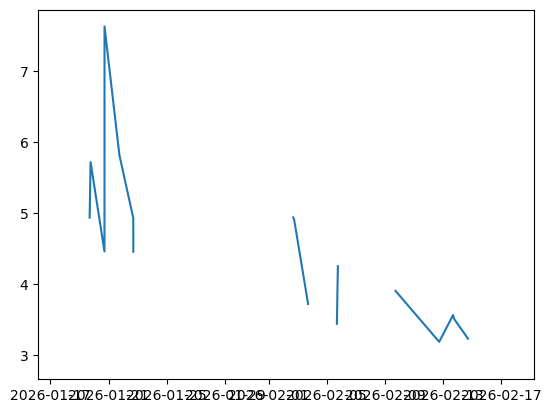

In [ ]:
plt.plot(df['time'], df['chlor_a'])

In [40]:
create_map_gif_from_netcdf_files(
    file_paths=paths_bgc,
    variable_name='chlor_a',
    min_lon=min_lon,
    min_lat=min_lat,
    max_lon=max_lon,
    max_lat=max_lat,
    vmin = 0.001,
    vmax = 50,
    output_file='chesapeake_bay_chlor.gif',
    duration=500,
    cmap='viridis',
    points = [(-76.1, 37.2),(-76.2, 37.95), (-76.61, 38.19), (-77.25, 38.35)]
)

Processing 50 NetCDF files...

Inspecting first file: PACE_OCI.20260117T171006.L2.OC_BGC.V3_1.NRT.nc
✓ Found 'chlor_a'
Data dimensions: ('number_of_lines', 'pixels_per_line')
Data shape: (1710, 1272)

✓ Will plot 4 point(s) as red X markers:
  Point 1: lon=-76.1000, lat=37.2000
  Point 2: lon=-76.2000, lat=37.9500
  Point 3: lon=-76.6100, lat=38.1900
  Point 4: lon=-77.2500, lat=38.3500

Using manual color scale:
vmin: 0.001
vmax: 50.000
Map extent: [-77.38, -75.75] x [36.91, 39]
Processed 1/50 frames
Processed 10/50 frames
Processed 20/50 frames
Processed 30/50 frames
Processed 40/50 frames
Processed 50/50 frames

✓ GIF saved to chesapeake_bay_chlor.gif with 50 frames


'chesapeake_bay_chlor.gif'

In [ ]:
# convert gif to .mp4 easily
from moviepy.editor import VideoFileClip
VideoFileClip("chesapeake_bay_chlor.gif").write_videofile("chesapeake_bay_chlor.mp4")

Moviepy - Building video chesapeake_bay_chlor.mp4.
Moviepy - Writing video chesapeake_bay_chlor.mp4



Moviepy - Done !
Moviepy - video ready chesapeake_bay_chlor.mp4


No results found for reprocessed surface reflectance data product, searching for near real time product instead.


QUEUEING TASKS | :   0%|          | 0/50 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/50 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/50 [00:00<?, ?it/s]

Number of bgc granules: 50


In [27]:
paths_aop

['c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260117T171006.L2.OC_AOP.V3_1.NRT.nc',
 'c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260117T171506.L2.OC_AOP.V3_1.NRT.nc',
 'c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260118T174503.L2.OC_AOP.V3_1.NRT.nc',
 'c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260119T164639.L2.OC_AOP.V3_1.NRT.nc',
 'c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260119T181959.L2.OC_AOP.V3_1.NRT.nc',
 'c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260120T171636.L2.OC_AOP.V3_1.NRT.nc',
 'c:\\Users\\gtrolley\\Documents\\GitHub\\pace-rapid-response\\PRR_OC\\dc_sewage\\local\\data\\PACE_OCI.20260120T172136.L2.OC_AOP.V3_1.N

In [28]:
create_map_gif_from_netcdf_files(
    file_paths=paths_aop,
    variable_name='avw',
    vmin = 300,
    vmax = 700,
    min_lon=min_lon,
    min_lat=min_lat,
    max_lon=max_lon,
    max_lat=max_lat,
    output_file='chesapeake_bay_avw.gif',
    duration=500,
    cmap='viridis'
)

Processing 50 NetCDF files...

Inspecting first file: PACE_OCI.20260117T171006.L2.OC_AOP.V3_1.NRT.nc
✓ Found 'avw'
Data dimensions: ('number_of_lines', 'pixels_per_line')
Data shape: (1710, 1272)

Using manual color scale:
vmin: 300.000
vmax: 700.000
Map extent: [-77.38, -75.75] x [36.91, 39]
Processed 1/50 frames
Processed 10/50 frames
Processed 20/50 frames
Processed 30/50 frames
Processed 40/50 frames
Processed 50/50 frames

✓ GIF saved to chesapeake_bay_avw.gif with 50 frames


'chesapeake_bay_avw.gif'

No results found for reprocessed surface reflectance data product, searching for near real time product instead.


QUEUEING TASKS | :   0%|          | 0/50 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/50 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/50 [00:00<?, ?it/s]

Number of IOP granules: 50


### Time series of chl-a, adg_442, adg_s at points of interest

In [16]:
def get_var_time_series_aop(f_list, vars, rrs_wvls, lon, lat):
    # function to retrieve time series of values from L2 file list at a given point
    # return a pandas df with first col - datetime, column 1 and onward, values at the given point
    # vars is a list of vars in the L2 file to make time series of

    rows = []
    for file in f_list:
        row_dict = {}
        # open file correctly
        dt = xr.open_datatree(file,decode_timedelta=False)
        #record time
        time = pd.to_datetime(dt.attrs['time_coverage_start'])
        row_dict['time'] = time

        for var in vars:
            da = xr.DataArray(
                dt["geophysical_data"][var],
                coords={
                    "lat": dt["navigation_data"]["latitude"],
                    "lon": dt["navigation_data"]["longitude"],
                },
            )
            da = da.set_xindex(("lat", "lon"), xr.indexes.NDPointIndex)  # the new part!

            value = da.sel({"lat": lat, "lon": lon}, method="nearest").values
            row_dict[var] = value

        for wvl in rrs_wvls:
            da = xr.DataArray(
                dt["geophysical_data"]['Rrs'],
                coords={
                    "lat": dt["navigation_data"]["latitude"],
                    "lon": dt["navigation_data"]["longitude"],
                },
            )
            da = da.set_xindex(("lat", "lon"), xr.indexes.NDPointIndex)  # the new part!

            #value = da.sel(wavelength_3d=wvl).sel({"lat": lat, "lon": lon}, method="nearest").values
            value = da.sel(wavelength_3d=np.where(dt['sensor_band_parameters']['wavelength_3d'] == wvl)[0][0]).sel({"lat": lat, "lon": lon}, method="nearest").values
            #print('ok')
            row_dict['rrs'+str(int(wvl))] = value
            
        rows.append(row_dict)
        
    df = pd.DataFrame(rows)
    return df
        


In [110]:
#da.sel(wavelength_3d=413)

da = get_var_time_series_aop(paths_aop[0:1], ['avw'], [380, 413, ], -76.1, 37.2)

ok
ok


In [112]:
da

,time,avw,rrs380,rrs413
0,2026-01-17 17:10:06.074000+00:00,530.8112,0.0041480027,0.0044919997


In [106]:
da.load()
da
wl = 413
da.sel(wavelength_3d=np.where(dt['sensor_band_parameters']['wavelength_3d'] == wl)[0][0]).sel({"lat": 37.2, "lon": -76.1}, method="nearest").values

array(0.004492, dtype=float32)

In [101]:

np.where(dt['sensor_band_parameters']['wavelength_3d'] == 413)[0][0]

np.int64(27)

In [ ]:
# points:
#A: (-77.25, 38.35)
#B: (-76.61, 38.19)
#C: (-76.2, 37.95)
#D: (-76.1, 37.2)

In [18]:
# intitialize dictionary with a,b,c,d and lat lon points, before populating with time series data

points = {name: {'lon': lon, 'lat': lat} for name, lon, lat in [('A', -77.25, 38.35), ('B', -76.61, 38.19), ('C', -76.2, 37.95), ('D', -76.1, 37.2), ('E',-76.845, 38.218)]}

In [19]:
# loop to retrieve all varsof interst on all days at points of interest
for name in ['A', 'B', 'C', 'D', 'E']:
    print(name)
    print('doing chl')
    points[name]['chlor_a'] = get_var_time_series(paths_bgc, ['chlor_a'], points[name]['lon'],points[name]['lat'])
    print('doing adg')
    points[name]['iops'] = get_var_time_series(paths_iop, ['adg_442'], points[name]['lon'],points[name]['lat'])
    print('doing aops')
    # to same dictionatry, add sub-dict for aops, which has avw, rrs380, 412 (413), 443 (442), 490, 532, 547, 665
    points[name]['aops'] = get_var_time_series_aop(paths_aop, ['avw'], [380, 413, 442, 490, 532, 547, 665], points[name]['lon'], points[name]['lat'])

    #16 min

A
doing chl
doing adg
doing aops
B
doing chl
doing adg
doing aops
C
doing chl
doing adg
doing aops
D
doing chl
doing adg
doing aops
E
doing chl
doing adg
doing aops


In [23]:
import numpy as np

In [24]:
# now, code to add columns for a380, a412, Sg275:295, DOC2

for name in ['A', 'B', 'C', 'D', 'E']:
    b0=-2.677; b1=-0.598; b2=-1.319; b3=2.667; b4=-2.502; b5=0.803; b6=0.491; b7=0.19 # a380 coeffs
    points[name]['aops']['ag380'] = np.exp(
        b0 + 
        b1 * np.log(points[name]['aops']['rrs380']) +
        b2 * np.log(points[name]['aops']['rrs413']) +
        b3 * np.log(points[name]['aops']['rrs442']) +
        b4 * np.log(points[name]['aops']['rrs490']) +
        b5 * np.log(points[name]['aops']['rrs532']) +
        b6 * np.log(points[name]['aops']['rrs547']) +
        b7 * np.log(points[name]['aops']['rrs665'])
    )

    #ag412
    b0=-3.176; b1=-0.53; b2=-1.423; b3=2.714; b4=-2.513; b5=0.681; b6=0.602; b7=0.2
    points[name]['aops']['ag412'] = np.exp(
        b0 + 
        b1 * np.log(points[name]['aops']['rrs380']) +
        b2 * np.log(points[name]['aops']['rrs413']) +
        b3 * np.log(points[name]['aops']['rrs442']) +
        b4 * np.log(points[name]['aops']['rrs490']) +
        b5 * np.log(points[name]['aops']['rrs532']) +
        b6 * np.log(points[name]['aops']['rrs547']) +
        b7 * np.log(points[name]['aops']['rrs665'])
    )   
    #Sg275:295
    b0=-3.085; b1=0.0747; b2=0.824; b3=-1.416; b4=1.075; b5=-0.459
    points[name]['aops']['s275_295'] = np.exp(
        b0 + 
        b1 * np.log(points[name]['aops']['rrs380']) +
        b2 * np.log(points[name]['aops']['rrs413']) +
        b3 * np.log(points[name]['aops']['rrs442']) +
        b4 * np.log(points[name]['aops']['rrs490']) +
        b5 * np.log(points[name]['aops']['rrs547'])
    )   

    #DOC2
    A=-0.004649; B=0.003305 #these are Nov1 thru may 15 coefficients
    points[name]['aops']['DOC'] = 1/((A*np.log(points[name]['aops']['ag412'])) + B)

TypeError: loop of ufunc does not support argument 0 of type numpy.ndarray which has no callable log method

In [25]:
### MAJOR CAVEAT: if any of the used rrs wavelengths are negative, the derived values are nan

for name in ['A', 'B', 'C', 'D', 'E']:
    df = points[name]['aops']
    
    # First, flatten all the rrs columns to extract scalar values
    rrs_cols = ['rrs380', 'rrs413', 'rrs442', 'rrs490', 'rrs532', 'rrs547', 'rrs665']
    for col in rrs_cols:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: x.item() if hasattr(x, 'item') else x)
    
    # ag380
    b0=-2.677; b1=-0.598; b2=-1.319; b3=2.667; b4=-2.502; b5=0.803; b6=0.491; b7=0.19
    df['ag380'] = np.exp(
        b0 + 
        b1 * np.log(df['rrs380']) +
        b2 * np.log(df['rrs413']) +
        b3 * np.log(df['rrs442']) +
        b4 * np.log(df['rrs490']) +
        b5 * np.log(df['rrs532']) +
        b6 * np.log(df['rrs547']) +
        b7 * np.log(df['rrs665'])
    )

    # ag412
    b0=-3.176; b1=-0.53; b2=-1.423; b3=2.714; b4=-2.513; b5=0.681; b6=0.602; b7=0.2
    df['ag412'] = np.exp(
        b0 + 
        b1 * np.log(df['rrs380']) +
        b2 * np.log(df['rrs413']) +
        b3 * np.log(df['rrs442']) +
        b4 * np.log(df['rrs490']) +
        b5 * np.log(df['rrs532']) +
        b6 * np.log(df['rrs547']) +
        b7 * np.log(df['rrs665'])
    )
    
    # Sg275:295
    b0=-3.085; b1=0.0747; b2=0.824; b3=-1.416; b4=1.075; b5=-0.459
    df['s275_295'] = np.exp(
        b0 + 
        b1 * np.log(df['rrs380']) +
        b2 * np.log(df['rrs413']) +
        b3 * np.log(df['rrs442']) +
        b4 * np.log(df['rrs490']) +
        b5 * np.log(df['rrs547'])
    )

    # DOC2
    A=-0.004649; B=0.003305
    df['DOC'] = 1/((A*np.log(df['ag412'])) + B)

c:\Users\gtrolley\AppData\Local\miniforge3\envs\prr\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gtrolley\AppData\Local\miniforge3\envs\prr\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gtrolley\AppData\Local\miniforge3\envs\prr\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gtrolley\AppData\Local\miniforge3\envs\prr\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gtrolley\AppData\Local\miniforge3\envs\prr\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, 

In [26]:
import pickle



with open('potomac_ata_extracted.pkl', 'wb') as f:
    pickle.dump(points, f)

#     # Read it back
# with open('potomac_ata_extracted.pkl', 'rb') as f:
#     points = pickle.load(f)

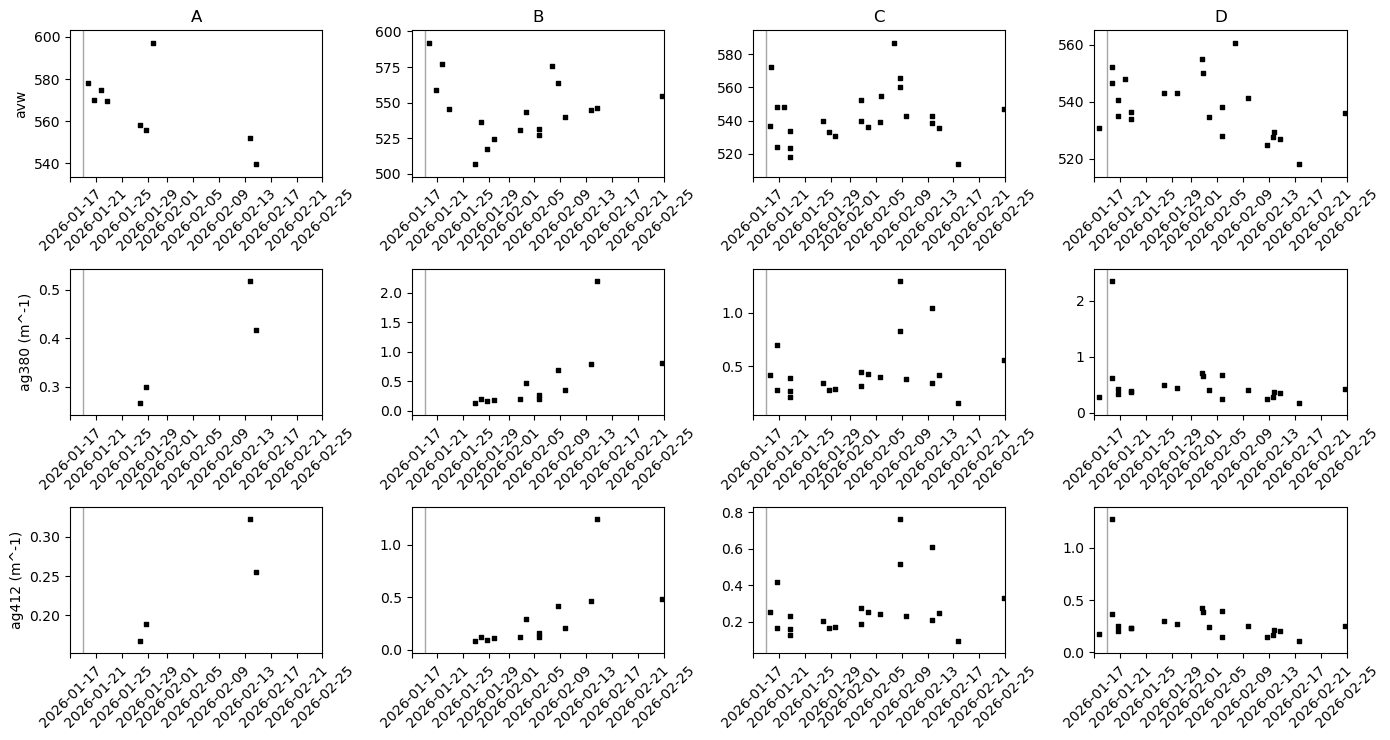

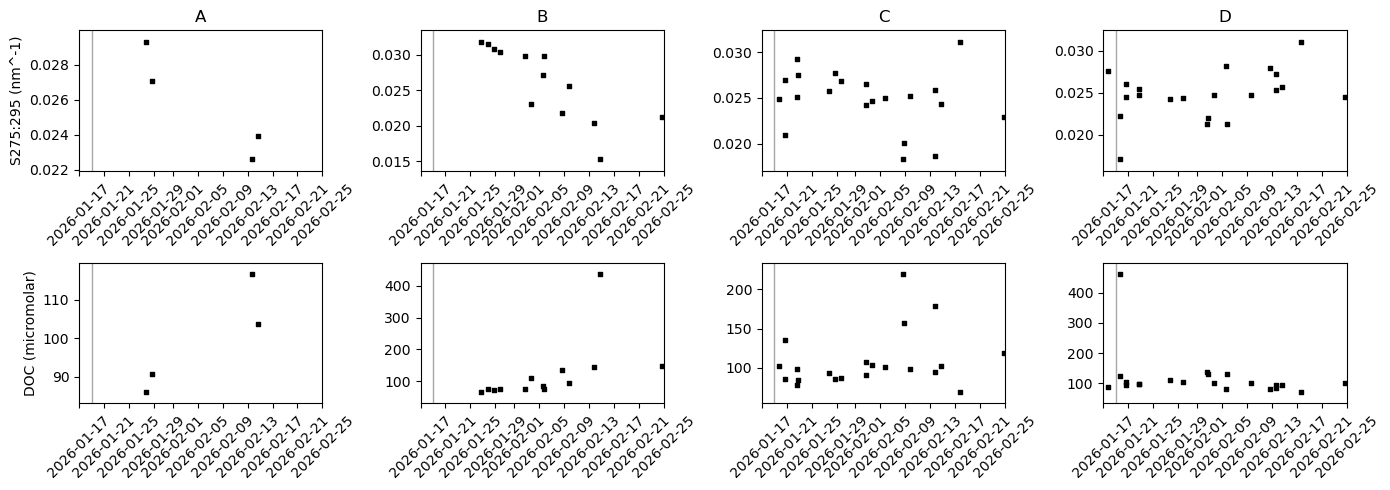

In [28]:
# Define scatter plot appearance
marker_shape = 's'  # Options: 'o', 's', '^', 'v', 'D', '*', '+', 'x', etc.
marker_color = 'k'  # Or use hex like '#1f77b4' or RGB tuple
marker_size = 5  # Optional: control size

# Define the variables and their labels
variables_plot1 = ['avw', 'ag380', 'ag412']
ylabels_plot1 = ['avw', 'ag380 (m^-1)', 'ag412 (m^-1)']

variables_plot2 = ['s275_295', 'DOC']
ylabels_plot2 = ['S275:295 (nm^-1)', 'DOC (micromolar)']

# Define date limits and reference line
import pandas as pd
start_date = pd.Timestamp('2026-01-17')
end_date = pd.Timestamp('2026-02-25')
reference_date = pd.Timestamp('2026-01-19')

# ===== FIRST PLOT: First 3 rows (avw, ag380, ag412) =====
fig1, axes1 = plt.subplots(nrows=3, ncols=4, figsize=(14, 7.5))
for ax in axes1.flat:
    ax.tick_params(axis='x', rotation=45)

# Loop through each point (columns)
for col, point in enumerate(['A', 'B', 'C', 'D']):
    # Loop through each variable (rows)
    for row, (var, ylabel) in enumerate(zip(variables_plot1, ylabels_plot1)):
        # Plot the data
        axes1[row, col].scatter(points[point]['aops']['time'], 
                                points[point]['aops'][var],
                                marker=marker_shape, color=marker_color, s=marker_size)
        
        # Set y-limits with padding
        data_min = np.nanmin(points[point]['aops'][var])
        data_max = np.nanmax(points[point]['aops'][var])
        padding = (data_max - data_min) * 0.1  # 10% padding
        if not np.isnan(data_min) and not np.isnan(data_max):
            axes1[row, col].set_ylim(data_min - padding, data_max + padding)
        
        # Set x-axis limits from Jan 17 to Feb 20
        axes1[row, col].set_xlim(left=start_date, right=end_date)
        
        # Add vertical line on Jan 19
        axes1[row, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
        
        # Set title for top row
        if row == 0:
            axes1[row, col].set_title(point)
        
        # Set ylabel for leftmost column
        if col == 0:
            axes1[row, col].set_ylabel(ylabel)

plt.tight_layout()

# ===== SECOND PLOT: Last 2 rows (s275_295, DOC) =====
fig2, axes2 = plt.subplots(nrows=2, ncols=4, figsize=(14, 5))
for ax in axes2.flat:
    ax.tick_params(axis='x', rotation=45)

# Loop through each point (columns)
for col, point in enumerate(['A', 'B', 'C', 'D']):
    # Loop through each variable (rows)
    for row, (var, ylabel) in enumerate(zip(variables_plot2, ylabels_plot2)):
        # Plot the data
        axes2[row, col].scatter(points[point]['aops']['time'], 
                                points[point]['aops'][var],
                                marker=marker_shape, color=marker_color, s=marker_size)
        
        # Set y-limits with padding
        data_min = np.nanmin(points[point]['aops'][var])
        data_max = np.nanmax(points[point]['aops'][var])
        padding = (data_max - data_min) * 0.1  # 10% padding
        if not np.isnan(data_min) and not np.isnan(data_max):
            axes2[row, col].set_ylim(data_min - padding, data_max + padding)
        
        # Set x-axis limits from Jan 17 to Feb 20
        axes2[row, col].set_xlim(left=start_date, right=end_date)
        
        # Add vertical line on Jan 19
        axes2[row, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
        
        # Set title for top row
        if row == 0:
            axes2[row, col].set_title(point)
        
        # Set ylabel for leftmost column
        if col == 0:
            axes2[row, col].set_ylabel(ylabel)

plt.tight_layout()

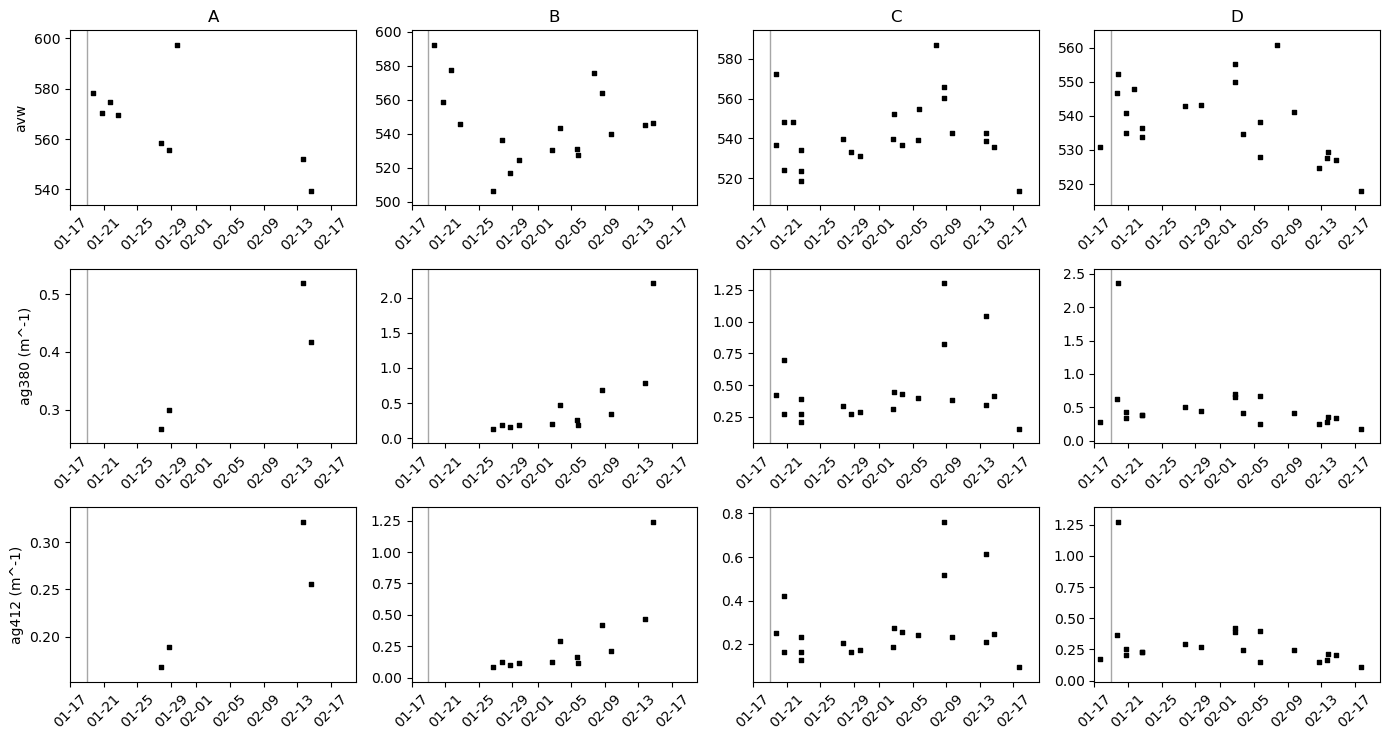

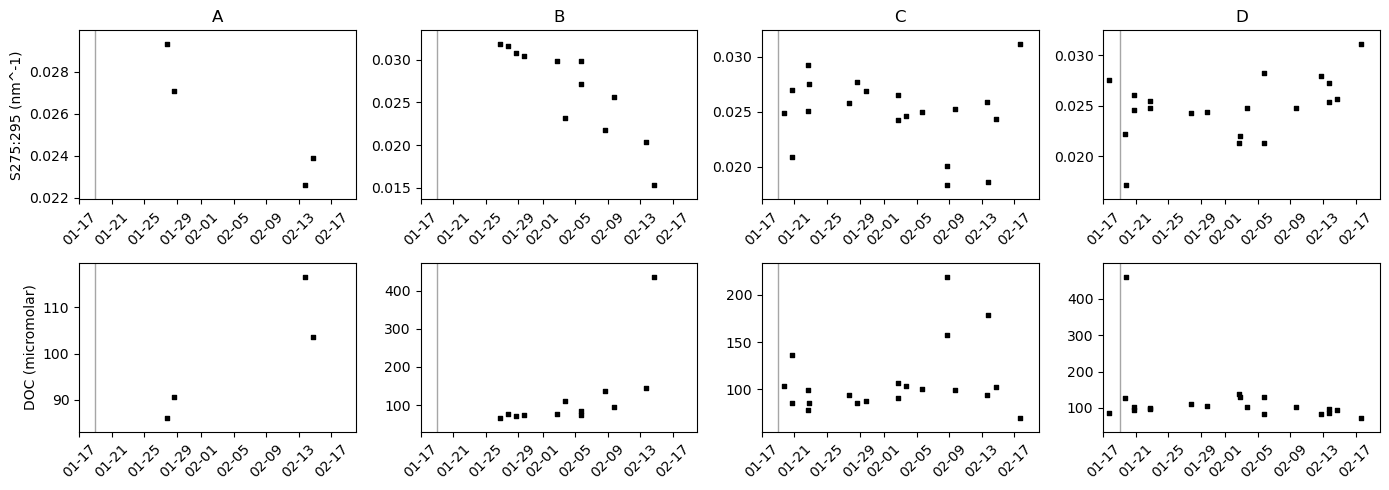

In [7]:
import matplotlib.dates as mdates

# Define scatter plot appearance
marker_shape = 's'  # Options: 'o', 's', '^', 'v', 'D', '*', '+', 'x', etc.
marker_color = 'k'  # Or use hex like '#1f77b4' or RGB tuple
marker_size = 5  # Optional: control size

# Define the variables and their labels
variables_plot1 = ['avw', 'ag380', 'ag412']
ylabels_plot1 = ['avw', 'ag380 (m^-1)', 'ag412 (m^-1)']

variables_plot2 = ['s275_295', 'DOC']
ylabels_plot2 = ['S275:295 (nm^-1)', 'DOC (micromolar)']

# Define date limits and reference line
import pandas as pd
start_date = pd.Timestamp('2026-01-17')
end_date = pd.Timestamp('2026-02-20')
reference_date = pd.Timestamp('2026-01-19')

# Create date formatter for mm-dd format
date_formatter = mdates.DateFormatter('%m-%d')

# ===== FIRST PLOT: First 3 rows (avw, ag380, ag412) =====
fig1, axes1 = plt.subplots(nrows=3, ncols=4, figsize=(14, 7.5))
for ax in axes1.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_formatter(date_formatter)  # Apply date format

# Loop through each point (columns)
for col, point in enumerate(['A', 'B', 'C', 'D']):
    # Loop through each variable (rows)
    for row, (var, ylabel) in enumerate(zip(variables_plot1, ylabels_plot1)):
        # Plot the data
        axes1[row, col].scatter(points[point]['aops']['time'], 
                                points[point]['aops'][var],
                                marker=marker_shape, color=marker_color, s=marker_size)
        
        # Set y-limits with padding
        data_min = np.nanmin(points[point]['aops'][var])
        data_max = np.nanmax(points[point]['aops'][var])
        padding = (data_max - data_min) * 0.1  # 10% padding
        if not np.isnan(data_min) and not np.isnan(data_max):
            axes1[row, col].set_ylim(data_min - padding, data_max + padding)
        
        # Set x-axis limits from Jan 17 to Feb 20
        axes1[row, col].set_xlim(left=start_date, right=end_date)
        
        # Add vertical line on Jan 19
        axes1[row, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
        
        # Set title for top row
        if row == 0:
            axes1[row, col].set_title(point)
        
        # Set ylabel for leftmost column
        if col == 0:
            axes1[row, col].set_ylabel(ylabel)

plt.tight_layout()

# ===== SECOND PLOT: Last 2 rows (s275_295, DOC) =====
fig2, axes2 = plt.subplots(nrows=2, ncols=4, figsize=(14, 5))
for ax in axes2.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_formatter(date_formatter)  # Apply date format

# Loop through each point (columns)
for col, point in enumerate(['A', 'B', 'C', 'D']):
    # Loop through each variable (rows)
    for row, (var, ylabel) in enumerate(zip(variables_plot2, ylabels_plot2)):
        # Plot the data
        axes2[row, col].scatter(points[point]['aops']['time'], 
                                points[point]['aops'][var],
                                marker=marker_shape, color=marker_color, s=marker_size)
        
        # Set y-limits with padding
        data_min = np.nanmin(points[point]['aops'][var])
        data_max = np.nanmax(points[point]['aops'][var])
        padding = (data_max - data_min) * 0.1  # 10% padding
        if not np.isnan(data_min) and not np.isnan(data_max):
            axes2[row, col].set_ylim(data_min - padding, data_max + padding)
        
        # Set x-axis limits from Jan 17 to Feb 20
        axes2[row, col].set_xlim(left=start_date, right=end_date)
        
        # Add vertical line on Jan 19
        axes2[row, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
        
        # Set title for top row
        if row == 0:
            axes2[row, col].set_title(point)
        
        # Set ylabel for leftmost column
        if col == 0:
            axes2[row, col].set_ylabel(ylabel)

plt.tight_layout()

In [30]:
points['B']['aops']

,time,avw,rrs380,rrs413,rrs442,rrs490,rrs532,rrs547,rrs665,ag380,ag412,s275_295,DOC
0,2026-01-17 17:10:06.074000+00:00,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-17 17:15:06.132000+00:00,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-01-18 17:45:03.154000+00:00,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-01-19 16:46:39.152000+00:00,592.18085,-0.001676,-0.001002,-0.000714,0.000784,0.002412,0.003026,0.000090,NaN,NaN,NaN,NaN
4,2026-01-19 18:19:59.180000+00:00,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-01-20 17:16:36.173000+00:00,558.5405,-0.000610,-0.000330,0.000146,0.001474,0.002604,0.003128,0.000454,NaN,NaN,NaN,NaN
6,2026-01-20 17:21:36.056000+00:00,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2026-01-21 17:51:33.077000+00:00,577.3003,-0.002196,-0.001048,-0.000256,0.001542,0.003208,0.003714,0.000674,NaN,NaN,NaN,NaN
8,2026-01-22 16:48:10.070000+00:00,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2026-01-22 16:53:10.128000+00:00,545.6196,-0.000166,0.000064,0.000172,0.001184,0.002530,0.002972,0.000184,NaN,NaN,NaN,NaN


In [124]:
points['D']['aops']

,time,avw,rrs380,rrs413,rrs442,rrs490,rrs532,rrs547,rrs665
0,2026-01-17 17:10:06.074000+00:00,530.8112,0.0041480027,0.0044919997,0.004950002,0.0073160008,0.0092939995,0.009688001,0.0030620024
1,2026-01-17 17:15:06.132000+00:00,nan,nan,nan,nan,nan,nan,nan,nan
2,2026-01-18 17:45:03.154000+00:00,nan,nan,nan,nan,nan,nan,nan,nan
3,2026-01-19 16:46:39.152000+00:00,546.7637,0.0020860024,0.003295999,0.0047520027,0.008216001,0.011078,0.011824001,0.0055899993
4,2026-01-19 18:19:59.180000+00:00,552.1857,0.00022800267,0.0017060004,0.0031020008,0.006786,0.009688001,0.010658,0.004640002
5,2026-01-20 17:16:36.173000+00:00,534.9609,0.003556002,0.0041320026,0.004907999,0.007580001,0.009642001,0.010242,0.0035280026
6,2026-01-20 17:21:36.056000+00:00,540.7346,0.0022320002,0.0027160011,0.0031620003,0.0051300004,0.007178001,0.007952001,0.0026820004
7,2026-01-21 17:51:33.077000+00:00,547.9018,-4.8000365e-05,0.0018080026,0.003444001,0.0070660003,0.009892002,0.010608003,0.004044
8,2026-01-22 16:48:10.070000+00:00,536.5743,0.0029220022,0.0038800016,0.0044800006,0.006836001,0.009006001,0.009725999,0.003444001
9,2026-01-22 16:53:10.128000+00:00,533.84155,0.0033439994,0.0038719997,0.0047040023,0.0070159994,0.0090120025,0.009600002,0.0032979995


In [125]:
points['A']['aops']

,time,avw,rrs380,rrs413,rrs442,rrs490,rrs532,rrs547,rrs665
0,2026-01-17 17:10:06.074000+00:00,nan,nan,nan,nan,nan,nan,nan,nan
1,2026-01-17 17:15:06.132000+00:00,nan,nan,nan,nan,nan,nan,nan,nan
2,2026-01-18 17:45:03.154000+00:00,nan,nan,nan,nan,nan,nan,nan,nan
3,2026-01-19 16:46:39.152000+00:00,578.1382,-0.0011059977,0.00015800074,0.0010700002,0.0036280006,0.0075520016,0.009016,0.0058200024
4,2026-01-19 18:19:59.180000+00:00,nan,nan,nan,nan,nan,nan,nan,nan
5,2026-01-20 17:16:36.173000+00:00,nan,nan,nan,nan,nan,nan,nan,nan
6,2026-01-20 17:21:36.056000+00:00,570.26355,-0.00027199835,0.00073000044,0.0017260015,0.0037360005,0.0068080015,0.0079740025,0.0047480017
7,2026-01-21 17:51:33.077000+00:00,574.73816,-0.001828,-0.00014399737,0.0013580024,0.0041659996,0.00832,0.009649999,0.0054600015
8,2026-01-22 16:48:10.070000+00:00,nan,nan,nan,nan,nan,nan,nan,nan
9,2026-01-22 16:53:10.128000+00:00,569.3947,-0.00022799894,0.0010440014,0.0019979998,0.004198,0.0076720007,0.008958001,0.0058000013


In [116]:
# to same dictionatry, add sub-dict for aops, which has avw, rrs380, 412 (413), 443 (442), 490, 532, 547, 665
for name in ['A', 'B', 'C', 'D']:
    print(name)
    points[name]['aops'] = get_var_time_series_aop(paths_aop, ['avw'], [380, 413, 442, 490, 532, 547, 665], -76.1, 37.2)

A
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok

KeyboardInterrupt: 

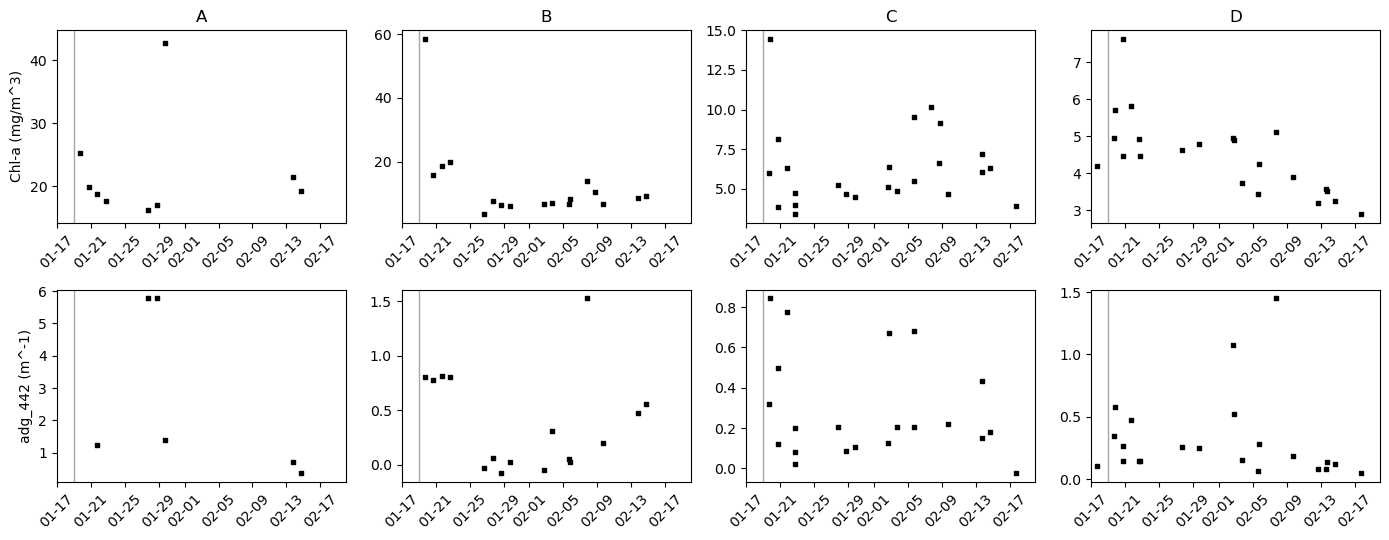

In [8]:
import matplotlib.dates as mdates

# Define scatter plot appearance
marker_shape = 's'  # Options: 'o', 's', '^', 'v', 'D', '*', '+', 'x', etc.
marker_color = 'k'  # Or use hex like '#1f77b4' or RGB tuple
marker_size = 5  # Optional: control size

# Define date limits and reference line
import pandas as pd
start_date = pd.Timestamp('2026-01-17')
end_date = pd.Timestamp('2026-02-20')
reference_date = pd.Timestamp('2026-01-19')

# Create date formatter for mm-dd format
date_formatter = mdates.DateFormatter('%m-%d')

# make 2x4 array of subplots to show time series, col0 = A, col1 = B, row1 = chla, etc
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(14, 5.5))
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_formatter(date_formatter)  # Apply date format

# plots for col 1:
point = 'A'
col = 0
axes[0, col].scatter(points[point]['chlor_a']['time'], points[point]['chlor_a']['chlor_a'], 
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[0, col].set_ylim(np.nanmin(points[point]['chlor_a']['chlor_a'])-2, 
                      np.nanmax(points[point]['chlor_a']['chlor_a'])+2)
axes[0, col].set_xlim(left=start_date, right=end_date)
axes[0, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
axes[0, col].set_title(point)
axes[0, col].set_ylabel('Chl-a (mg/m^3)')
axes[1, col].scatter(points[point]['iops']['time'], points[point]['iops']['adg_442'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[1, col].set_xlim(left=start_date, right=end_date)
axes[1, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
axes[1, col].set_ylabel('adg_442 (m^-1)')

# plots for col 2:
point = 'B'
col = 1
axes[0, col].scatter(points[point]['chlor_a']['time'], points[point]['chlor_a']['chlor_a'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[0, col].set_xlim(left=start_date, right=end_date)
axes[0, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
axes[0, col].set_title(point)
axes[1, col].scatter(points[point]['iops']['time'], points[point]['iops']['adg_442'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[1, col].set_xlim(left=start_date, right=end_date)
axes[1, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)

# plots for col 3:
point = 'C'
col = 2
axes[0, col].scatter(points[point]['chlor_a']['time'], points[point]['chlor_a']['chlor_a'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[0, col].set_xlim(left=start_date, right=end_date)
axes[0, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
axes[0, col].set_title(point)
axes[1, col].scatter(points[point]['iops']['time'], points[point]['iops']['adg_442'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[1, col].set_xlim(left=start_date, right=end_date)
axes[1, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)

# plots for col 4:
point = 'D'
col = 3
axes[0, col].scatter(points[point]['chlor_a']['time'], points[point]['chlor_a']['chlor_a'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[0, col].set_xlim(left=start_date, right=end_date)
axes[0, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
axes[0, col].set_title(point)
axes[1, col].scatter(points[point]['iops']['time'], points[point]['iops']['adg_442'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[1, col].set_xlim(left=start_date, right=end_date)
axes[1, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)

plt.tight_layout()

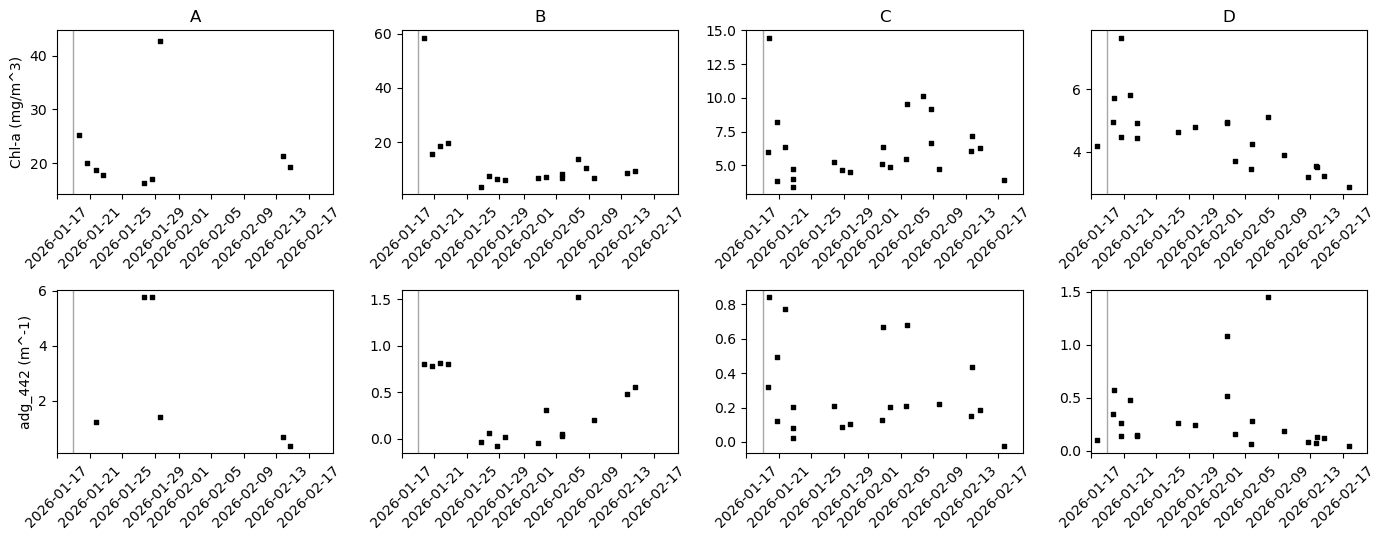

In [36]:
# Define scatter plot appearance
marker_shape = 's'  # Options: 'o', 's', '^', 'v', 'D', '*', '+', 'x', etc.
marker_color = 'k'  # Or use hex like '#1f77b4' or RGB tuple
marker_size = 5  # Optional: control size

# Define date limits and reference line
import pandas as pd
start_date = pd.Timestamp('2026-01-17')
end_date = pd.Timestamp('2026-02-20')
reference_date = pd.Timestamp('2026-01-19')

# make 2x4 array of subplots to show time series, col0 = A, col1 = B, row1 = chla, etc
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(14, 5.5))
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

# plots for col 1:
point = 'A'
col = 0
axes[0, col].scatter(points[point]['chlor_a']['time'], points[point]['chlor_a']['chlor_a'], 
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[0, col].set_ylim(np.nanmin(points[point]['chlor_a']['chlor_a'])-2, 
                      np.nanmax(points[point]['chlor_a']['chlor_a'])+2)
axes[0, col].set_xlim(left=start_date, right=end_date)
axes[0, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
axes[0, col].set_title(point)
axes[0, col].set_ylabel('Chl-a (mg/m^3)')
axes[1, col].scatter(points[point]['iops']['time'], points[point]['iops']['adg_442'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[1, col].set_xlim(left=start_date, right=end_date)
axes[1, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
axes[1, col].set_ylabel('adg_442 (m^-1)')

# plots for col 2:
point = 'B'
col = 1
axes[0, col].scatter(points[point]['chlor_a']['time'], points[point]['chlor_a']['chlor_a'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[0, col].set_xlim(left=start_date, right=end_date)
axes[0, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
axes[0, col].set_title(point)
axes[1, col].scatter(points[point]['iops']['time'], points[point]['iops']['adg_442'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[1, col].set_xlim(left=start_date, right=end_date)
axes[1, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)

# plots for col 3:
point = 'C'
col = 2
axes[0, col].scatter(points[point]['chlor_a']['time'], points[point]['chlor_a']['chlor_a'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[0, col].set_xlim(left=start_date, right=end_date)
axes[0, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
axes[0, col].set_title(point)
axes[1, col].scatter(points[point]['iops']['time'], points[point]['iops']['adg_442'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[1, col].set_xlim(left=start_date, right=end_date)
axes[1, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)

# plots for col 4:
point = 'D'
col = 3
axes[0, col].scatter(points[point]['chlor_a']['time'], points[point]['chlor_a']['chlor_a'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[0, col].set_xlim(left=start_date, right=end_date)
axes[0, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)
axes[0, col].set_title(point)
axes[1, col].scatter(points[point]['iops']['time'], points[point]['iops']['adg_442'],
                     marker=marker_shape, color=marker_color, s=marker_size)
axes[1, col].set_xlim(left=start_date, right=end_date)
axes[1, col].axvline(reference_date, color='grey', linewidth=1, linestyle='-', alpha=0.7)

plt.tight_layout()

In [89]:
points['A']['chlor_a']

,time,chlor_a
0,2026-01-17 17:10:06.074000+00:00,nan
1,2026-01-17 17:15:06.132000+00:00,nan
2,2026-01-18 17:45:03.154000+00:00,nan
3,2026-01-19 16:46:39.152000+00:00,25.202318
4,2026-01-19 18:19:59.180000+00:00,nan
5,2026-01-20 17:16:36.173000+00:00,nan
6,2026-01-20 17:21:36.056000+00:00,19.94806
7,2026-01-21 17:51:33.077000+00:00,18.751284
8,2026-01-22 16:48:10.070000+00:00,nan
9,2026-01-22 16:53:10.128000+00:00,17.69821


In [74]:
points['A']['chlor_a']

,time,chlor_a
0,2026-01-17 17:10:06.074000+00:00,nan
1,2026-01-17 17:15:06.132000+00:00,nan
2,2026-01-18 17:45:03.154000+00:00,nan
3,2026-01-19 16:46:39.152000+00:00,25.202318
4,2026-01-19 18:19:59.180000+00:00,nan
5,2026-01-20 17:16:36.173000+00:00,nan
6,2026-01-20 17:21:36.056000+00:00,19.94806
7,2026-01-21 17:51:33.077000+00:00,18.751284
8,2026-01-22 16:48:10.070000+00:00,nan
9,2026-01-22 16:53:10.128000+00:00,17.69821


In [58]:
points['D']['chlor_a']

,time,chlor_a
0,2026-01-17 17:10:06.074000+00:00,4.1817822
1,2026-01-17 17:15:06.132000+00:00,nan
2,2026-01-18 17:45:03.154000+00:00,nan
3,2026-01-19 16:46:39.152000+00:00,4.938687
4,2026-01-19 18:19:59.180000+00:00,5.719801
5,2026-01-20 17:16:36.173000+00:00,4.4630537
6,2026-01-20 17:21:36.056000+00:00,7.62979
7,2026-01-21 17:51:33.077000+00:00,5.8218946
8,2026-01-22 16:48:10.070000+00:00,4.9321384
9,2026-01-22 16:53:10.128000+00:00,4.457889


In [30]:
da = xr.open_datatree(paths_aop[0])
da

C:\Users\gtrolley\AppData\Local\Temp\ipykernel_5196\1419483213.py:1: FutureWarning: In a future version, xarray will not decode the variable 'day' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  da = xr.open_datatree(paths_aop[0])
C:\Users\gtrolley\AppData\Local\Temp\ipykernel_5196\1419483213.py:1: FutureWarning: In a future version, xarray will not decode the variable 'msec' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray

<xarray.DataTree>
Group: /
│   Attributes: (12/47)
│       title:                             OCI Level-2 Data AOP
│       product_name:                      PACE_OCI.20260117T171006.L2.OC_AOP.V3_...
│       processing_version:                3.1
│       history:                           l2gen par=/data2/sdpsoper/vdc/vpu4/wor...
│       instrument:                        OCI
│       platform:                          PACE
│       ...                                ...
│       geospatial_lon_min:                -85.72842
│       startDirection:                    Ascending
│       endDirection:                      Ascending
│       day_night_flag:                    Day
│       earth_sun_distance_correction:     1.033235788345337
│       geospatial_bounds:                 POLYGON((-55.73360 40.97428, -85.72842...
├── Group: /sensor_band_parameters
│       Dimensions:        (number_of_bands: 286, number_of_reflective_bands: 286,
│                           wavelength_3d: 172)
│       Coordinates:
│         * wavelength_3d  (wavelength_3d) float64 1kB 346.0 348.0 351.0 ... 717.0 719.0
│       Dimensions without coordinates: number_of_bands, number_of_reflective_bands
│       Data variables:
│           wavelength     (number_of_bands) float64 2kB ...
│           vcal_gain      (number_of_reflective_bands) float32 1kB ...
│           vcal_offset    (number_of_reflective_bands) float32 1kB ...
│           F0             (number_of_reflective_bands) float32 1kB ...
│           aw             (number_of_reflective_bands) float32 1kB ...
│           bbw            (number_of_reflective_bands) float32 1kB ...
│           k_oz           (number_of_reflective_bands) float32 1kB ...
│           k_no2          (number_of_reflective_bands) float32 1kB ...
│           Tau_r          (number_of_reflective_bands) float32 1kB ...
├── Group: /scan_line_attributes
│       Dimensions:  (number_of_lines: 1710)
│       Dimensions without coordinates: number_of_lines
│       Data variables: (12/13)
│           year     (number_of_lines) float64 14kB ...
│           day      (number_of_lines) timedelta64[ns] 14kB ...
│           msec     (number_of_lines) timedelta64[ns] 14kB ...
│           time     (number_of_lines) datetime64[ns] 14kB ...
│           detnum   (number_of_lines) float32 7kB ...
│           mside    (number_of_lines) float32 7kB ...
│           ...       ...
│           clon     (number_of_lines) float32 7kB ...
│           elon     (number_of_lines) float32 7kB ...
│           slat     (number_of_lines) float32 7kB ...
│           clat     (number_of_lines) float32 7kB ...
│           elat     (number_of_lines) float32 7kB ...
│           csol_z   (number_of_lines) float32 7kB ...
├── Group: /geophysical_data
│       Dimensions:   (number_of_lines: 1710, pixels_per_line: 1272, wavelength_3d: 172)
│       Dimensions without coordinates: number_of_lines, pixels_per_line, wavelength_3d
│       Data variables:
│           Rrs       (number_of_lines, pixels_per_line, wavelength_3d) float32 1GB ...
│           Rrs_unc   (number_of_lines, pixels_per_line, wavelength_3d) float32 1GB ...
│           aot_865   (number_of_lines, pixels_per_line) float32 9MB ...
│           angstrom  (number_of_lines, pixels_per_line) float32 9MB ...
│           avw       (number_of_lines, pixels_per_line) float32 9MB ...
│           nflh      (number_of_lines, pixels_per_line) float32 9MB ...
│           l2_flags  (number_of_lines, pixels_per_line) int32 9MB ...
├── Group: /navigation_data
│       Dimensions:    (number_of_lines: 1710, pixels_per_line: 1272)
│       Dimensions without coordinates: number_of_lines, pixels_per_line
│       Data variables:
│           longitude  (number_of_lines, pixels_per_line) float32 9MB ...
│           latitude   (number_of_lines, pixels_per_line) float32 9MB ...
│           tilt       (number_of_lines) float32 7kB ...
│       Attributes:
│           gringpointlongitude:  [-78.9282   -53.808937 -55.733604 -85.72842 ]
│    

In [31]:
create_map_gif_from_netcdf_files(
    file_paths=paths_iop,
    variable_name='adg_442',
    vmin = 0,
    vmax = 3,
    min_lon=min_lon,
    min_lat=min_lat,
    max_lon=max_lon,
    max_lat=max_lat,
    output_file='chesapeake_bay_iop.gif',
    duration=500,
    cmap='viridis'
)

Processing 50 NetCDF files...

Inspecting first file: PACE_OCI.20260117T171006.L2.OC_IOP.V3_1.NRT.nc
✓ Found 'adg_442'
Data dimensions: ('number_of_lines', 'pixels_per_line')
Data shape: (1710, 1272)

Using manual color scale:
vmin: 0.000
vmax: 3.000
Map extent: [-77.38, -75.75] x [36.91, 39]
Processed 1/50 frames
Processed 10/50 frames
Processed 20/50 frames
Processed 30/50 frames
Processed 40/50 frames
Processed 50/50 frames

✓ GIF saved to chesapeake_bay_iop.gif with 50 frames


'chesapeake_bay_iop.gif'